In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib.image as image
from skimage import io
from IPython.core.display import Image, display
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import warnings
warnings.filterwarnings('ignore')


In [2]:
n_sample = 100
random_state = 42

center_points = [[1, 1], [-1, -1], [1, -1]] # sinh ngẫu nhiên các điểm xung quanh vị trí tâm cố định 
# center_points = 3                           # tâm cụm được chọn ngẫu nhiên
X,y = make_blobs(n_samples=n_sample ,centers= center_points,
                 cluster_std=0.6,random_state=random_state)
print(f'Số chiều dữ liệu : {X.shape, y.shape}')
print(f'5 mẫu dữ liệu đầu tiên là {X[:5]}')

Số chiều dữ liệu : ((100, 2), (100,))
5 mẫu dữ liệu đầu tiên là [[ 1.28394257 -1.04369735]
 [ 0.49646949  0.81447257]
 [-2.15126273 -1.01590833]
 [ 0.71249546  0.88860461]
 [ 0.415191   -0.52774924]]


**Vẽ các điểm ảnh sử dụng matlib plot**

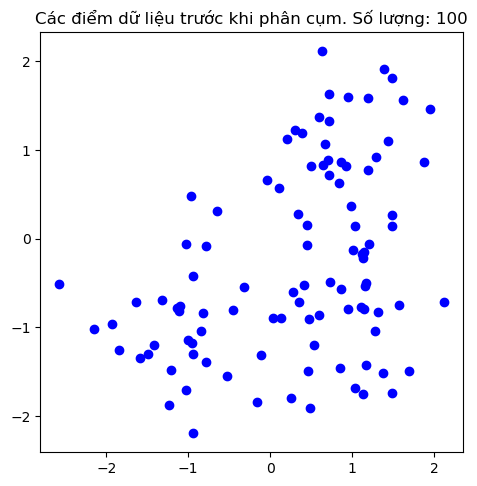

In [3]:
plt.figure(figsize = (12,12))
plt.subplot(221)
plt.scatter(X[:, 0], X[:, 1], c='blue') # c là tham số chọn màu sắc, có thể truyền vào string hoặc số id 1,2,3 ...
plt.title("Các điểm dữ liệu trước khi phân cụm. Số lượng: {}".format(n_sample))
plt.show()

#  Dựng giải thuật K-means và huấn luyện


In [4]:
k_cluster = 3
k_mean_model = KMeans(n_clusters=k_cluster, init='k-means++',
                      random_state=random_state)
k_mean_model.fit(X=X)
centers =  np.array(k_mean_model.cluster_centers_)
print("Tâm cụm sau khi training ({} tâm): \n".format(k_cluster),
      centers)

Tâm cụm sau khi training (3 tâm): 
 [[ 0.92215161 -0.89765135]
 [-1.09266234 -0.9783299 ]
 [ 0.90169798  0.9928998 ]]


Kết quả dự đoán cho 5 mẫu dữ liệu đầu tiên trong tập data: 

[0 2 1 2 0]


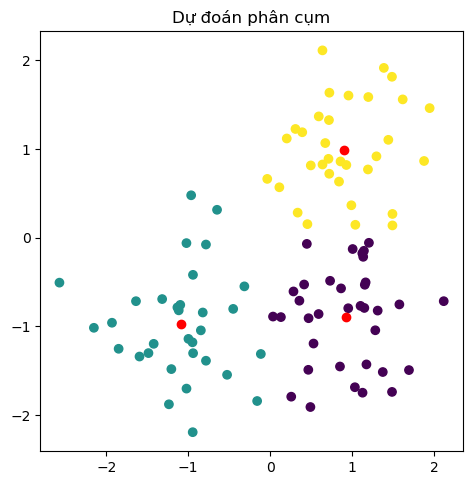

In [5]:
y_pred = k_mean_model.predict(X=X)
print("Kết quả dự đoán cho 5 mẫu dữ liệu đầu tiên trong tập data: \n")
print(y_pred[:5])
plt.figure(figsize = (12,12))
plt.subplot(221)
plt.scatter(X[:,0], X[:,1], c = y_pred)
plt.scatter(centers[:,0],centers[:,1], c= 'red')
plt.title('Dự đoán phân cụm')
plt.show()


# Bài tập 1
Yêu cầu: Thử nghiệm trường hợp dữ liệu sinh ra chỉ có 2 cụm nhưng huấn luyện K-means với các tham số k = 3,4,5 cụm

- Tự viết code sinh dữ liệu tương tự bên trên
- Xây dựng mô hình 3,4,5 cụm

Gợi ý: thay đổi tham số số cụm khi dựng giải thuật K-means

Kết quả phải ra được hình ảnh thể hiện đúng số tâm cụm và phân bố cụm. 

In [6]:
n_sample = 100
random_state = 42

center_points = [[1, 1], [-1, -1]] # sinh ngẫu nhiên các điểm xung quanh vị trí tâm cố định 
# center_points = 3                           # tâm cụm được chọn ngẫu nhiên
X,y = make_blobs(n_samples=n_sample ,centers= center_points,
                 cluster_std=0.6,random_state=random_state)
print(f'Số chiều dữ liệu : {X.shape, y.shape}')
print(f'5 mẫu dữ liệu đầu tiên là {X[:5]}')

Số chiều dữ liệu : ((100, 2), (100,))
5 mẫu dữ liệu đầu tiên là [[-0.71605743 -1.04369735]
 [ 0.49646949  0.81447257]
 [-2.15126273 -1.01590833]
 [ 0.71249546  0.88860461]
 [-1.584809   -0.52774924]]


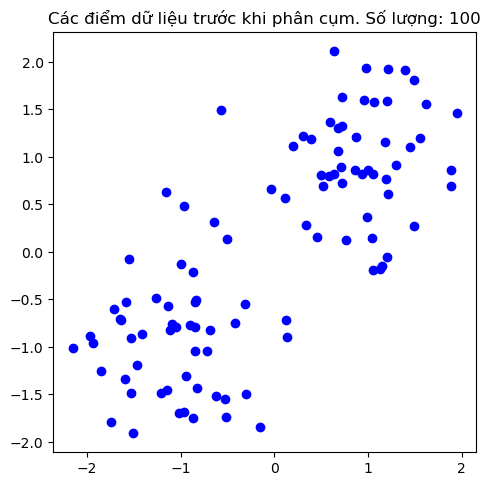

In [7]:
plt.figure(figsize = (12,12))
plt.subplot(221)
plt.scatter(X[:, 0], X[:, 1], c='blue') # c là tham số chọn màu sắc, có thể truyền vào string hoặc số id 1,2,3 ...
plt.title("Các điểm dữ liệu trước khi phân cụm. Số lượng: {}".format(n_sample))
plt.show()

Tâm cụm sau khi training (3 tâm): 
 [[ 0.71020718  0.02717392]
 [-1.10655755 -0.92056635]
 [ 0.95363176  1.20652867]]


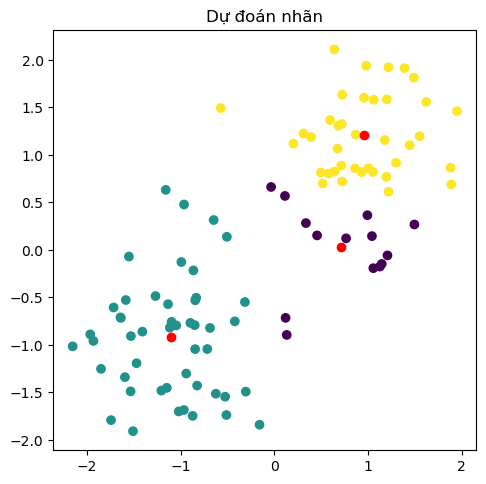

Tâm cụm sau khi training (4 tâm): 
 [[ 1.05979218  0.17188613]
 [-1.22635241 -1.30928465]
 [ 0.87400592  1.2046538 ]
 [-0.84207813 -0.41537128]]


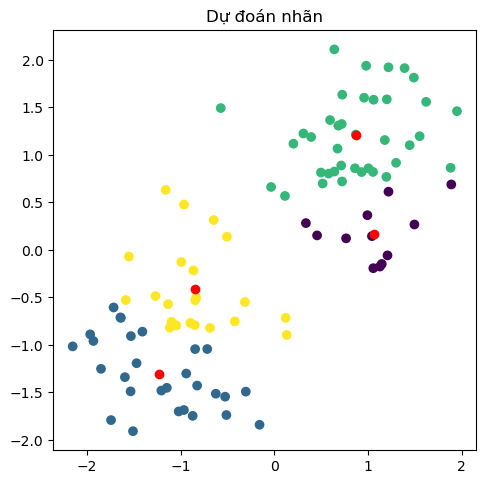

Tâm cụm sau khi training (5 tâm): 
 [[ 0.98461544  0.12487233]
 [-1.62306009 -0.96091401]
 [ 0.9886909   1.2150561 ]
 [-0.7121337  -1.14309571]
 [-0.6252155   0.43807383]]


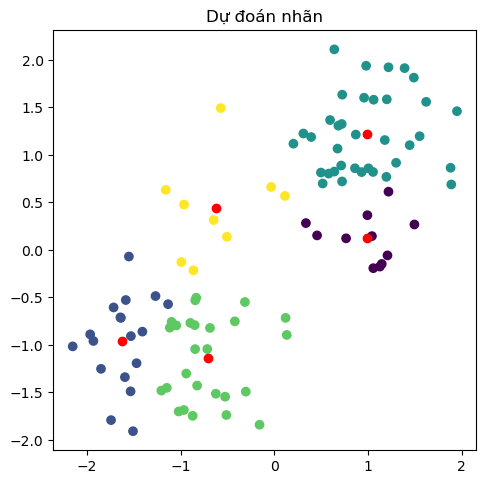

In [8]:
k_cluster = [3,4,5]
for i in k_cluster:
      k_mean_model = KMeans(n_clusters = i, random_state= random_state)
      k_mean_model.fit(X=X)
      centers =  np.array(k_mean_model.cluster_centers_)
      print("Tâm cụm sau khi training ({} tâm): \n".format(i),
            centers)
      y_pred = k_mean_model.predict(X)
      plt.figure(figsize = (12,12))
      plt.subplot(221)
      plt.scatter(x = X[: ,0], y = X[: ,1], c = y_pred)
      plt.scatter(x = centers[:,0], y = centers[:,1], c = 'red')
      plt.title("Dự đoán nhãn")
      plt.show()

# Ứng dụng nén ảnh 

- Đặt vấn đề:
    - Muốn xây dựng 1 hệ thống nén dữ liệu hình ảnh 
    - Có thể tuỳ chỉnh được độ sắc nét, giảm kích thước bộ nhớ, nhưng không làm sai lệch quá nhiều dưới mắt nhìn.  
- Giải pháp
    - Sử dụng giải thuật K-means, tự động phân cụm các điểm ảnh, giới hạn số lượng màu để giảm kích thước ảnh 
    - Mỗi điểm ảnh sẽ được quy về 1 cụm nào đó, mang giá trị màu bằng màu của tâm cụm. 


In [ ]:
%cd D:/du_lieu_huan_luyen
os.listdir()

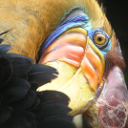

Dữ liệu ảnh trước khi reshape: (128, 128, 3)
Số chiều của dữ liệu hình ảnh:  (16384, 3)
Tổng số điểm ảnh là:  16384
Mỗi điểm ảnh có số chiều =  3


In [10]:

path_img = 'bird_small.png'

display(Image(path_img, width=250, unconfined=True))

img = io.imread(path_img)
print("Dữ liệu ảnh trước khi reshape:", img.shape)
data_img = (img / 255.0).reshape(-1,img.shape[2])

print("Số chiều của dữ liệu hình ảnh: ", data_img.shape)
print("Tổng số điểm ảnh là: ", data_img.shape[0])
print("Mỗi điểm ảnh có số chiều = ", data_img.shape[1])


## Xây dựng mô hình kmean để nén ảnh 
- Số lượng cụm chính là số lượng màu ta giữ lại 
- Số lượng cụm càng nhỏ thì kích thước ảnh cho ra càng nhỏ 

In [11]:
n_color = 10
k_mean_model = KMeans(n_clusters=n_color)

In [ ]:
k_mean_model.fit(data_img)

In [13]:
centers = k_mean_model.cluster_centers_
print(f'Số chiều tâm cụm là : {centers.shape}')
print(centers)

Số chiều tâm cụm là : (10, 3)
[[0.78345296 0.56485438 0.27335478]
 [0.10132957 0.10815783 0.09850235]
 [0.97156498 0.93901275 0.80030076]
 [0.54891122 0.66931717 0.8155976 ]
 [0.90634504 0.79780505 0.65888278]
 [0.27612016 0.24257023 0.22670023]
 [0.45886059 0.41157604 0.41957415]
 [0.86268182 0.70560621 0.44469246]
 [0.66188161 0.58082247 0.50835808]
 [0.55394949 0.40600839 0.20661466]]


In [18]:
img128 = centers[k_mean_model.labels_]
print(f'Kích thước trước khi nén: {img128.shape}')
img128 = np.reshape(img128, img.shape)
print(f'Kích thước sau khi nén: {img128.shape}')
image.imsave('img128.png',img128)

Kích thước trước khi nén: (16384, 3)
Kích thước sau khi nén: (128, 128, 3)


In [19]:

print('Size of compressed image: ' + str(os.path.getsize('img128.png')) + ' KB')
print('Size of original image: ' + str(os.path.getsize('bird_small.png')) + ' KB')

Size of compressed image: 7260 KB
Size of original image: 33031 KB


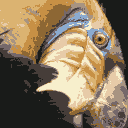

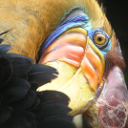

In [20]:
display(Image('img128.png', unconfined=True,width=250))
display(Image('bird_small.png', unconfined=True,width=250))

# Bài tập 2
Yêu cầu: Nén ảnh trên thành ảnh có số màu < 5 và kiểm tra 

Gợi ý: thay đổi tham số "số cụm" khi xây dựng K-means 

In [30]:
n_color = 4
k_mean_model = KMeans(n_clusters=4)
k_mean_model.fit(data_img)


,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [ ]:
centers = k_mean_model.cluster_centers_
img127 = centers[k_mean_model.labels_]

img127  = np.reshape(img127, img.shape)
image.imsave('img127.png', img127)


In [36]:
print(f"Size of pictures: {os.path.getsize('img127.png')} KB")
print(f"Size of pictures: {os.path.getsize('bird_small.png')} KB")


Size of pictures: 3428 KB
Size of pictures: 33031 KB


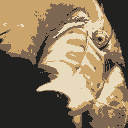

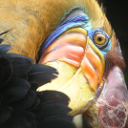

In [37]:
display(Image('img127.png', unconfined=True,width=250))
display(Image('bird_small.png', unconfined=True,width=250))